Import Libraries

In [7]:
%matplotlib inline

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Create Dataset

In [9]:
# Load the real dataset
data = pd.read_csv('system-1.csv')

# Engineer features similar to the pipeline
data["cpu"] = data["cpu-user"] + data["cpu-system"] + data["cpu-iowait"]
data["memory"] = (data["sys-mem-total"] - data["sys-mem-available"]) / data["sys-mem-total"]
data["response_time"] = (data["load-1m"] + data["load-5m"] + data["load-15m"]) / 3.0  # Using load average as proxy
data["error_count"] = data["sys-fork-rate"]  # Using fork rate as proxy for errors

# Select relevant columns
data = data[["cpu", "memory", "response_time", "error_count"]]

# Since we don't have true labels, we'll skip the true_label column
# The model will detect anomalies without ground truth

data.head()

,cpu,memory,response_time,error_count
0,0.0740,0.080053,0.193333,0.80
1,0.0870,0.079951,0.210000,0.95
2,0.0650,0.080020,0.170000,0.80
3,0.0780,0.080019,0.170000,0.85
4,0.0575,0.080017,0.140000,0.80


Train Model

In [10]:
model = IsolationForest(contamination=0.05, random_state=42)

features = ["cpu", "memory", "response_time", "error_count"]

data["pred"] = model.fit_predict(data[features])

# Convert output
data["pred"] = data["pred"].map({1: 0, -1: 1})

data.head()

,cpu,memory,response_time,error_count,pred
0,0.0740,0.080053,0.193333,0.80,0
1,0.0870,0.079951,0.210000,0.95,0
2,0.0650,0.080020,0.170000,0.80,0
3,0.0780,0.080019,0.170000,0.85,0
4,0.0575,0.080017,0.140000,0.80,0


Accuracy and Metrics

In [11]:
# Since we don't have ground truth labels, we can't compute accuracy
# Instead, let's see how many anomalies were detected
anomalies_detected = data["pred"].sum()
total_samples = len(data)
anomaly_percentage = (anomalies_detected / total_samples) * 100

print(f"✅ Anomalies detected: {anomalies_detected} out of {total_samples} samples ({anomaly_percentage:.2f}%)")

# Note: In unsupervised anomaly detection, we don't have true labels to compare against

✅ Anomalies detected: 4288 out of 85749 samples (5.00%)


Visualization

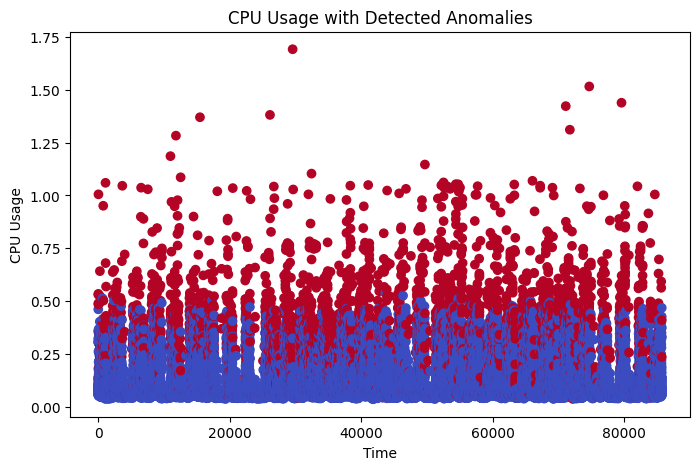

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(data.index, data["cpu"], c=data["pred"], cmap="coolwarm")
plt.title("CPU Usage with Detected Anomalies")
plt.xlabel("Time")
plt.ylabel("CPU Usage")
plt.show()

Detected Anamolies

In [13]:
data[data["pred"] == 1]

,cpu,memory,response_time,error_count,pred
20,0.5305,0.093798,0.250000,0.05,1
21,0.5345,0.095687,0.276667,0.10,1
22,0.4900,0.095481,0.273333,0.05,1
23,0.3600,0.079928,0.333333,6.20,1
28,0.4850,0.080328,0.246667,32.55,1
...,...,...,...,...,...
85636,0.2495,0.071732,0.066667,11.50,1
85654,0.5930,0.071722,0.203333,1.30,1
85657,0.5630,0.072057,0.150000,1.40,1
85738,0.2365,0.071805,0.080000,11.20,1
